In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [14]:
!pip install dagshub mlflow -q

In [15]:
import dagshub
import mlflow

dagshub.init(repo_owner='lshek22', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)
mlflow.set_experiment("Random_Forest_Training")

Initialized MLflow to track repo "lshek22/IEEE-CIS-Fraud-Detection"

Repository lshek22/IEEE-CIS-Fraud-Detection initialized!

<Experiment: artifact_location='mlflow-artifacts:/1f8b9abfffa84aceb0350696f8f5f5ba', creation_time=1777899929540, experiment_id='1', last_update_time=1777899929540, lifecycle_stage='active', name='Random_Forest_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [16]:
train = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv').merge(
        pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv'), on='TransactionID', how='left')
test = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv').merge(
       pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv'), on='TransactionID', how='left')


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score

X = train.drop(columns=['isFraud'])
y = train['isFraud']

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_cols)
])

In [18]:
def log_run(run_name, model, params, registered_model_name=None):
    with mlflow.start_run(run_name=run_name):
        p = Pipeline([('pre', preprocessor), ('model', model)])
        
        p.fit(X_train, y_train)
        
        tr_auc = roc_auc_score(y_train, p.predict_proba(X_train)[:,1])
        vl_auc = roc_auc_score(y_val,   p.predict_proba(X_val)[:,1])
        
        X_sample = X_train.sample(50000, random_state=42)
        y_sample = y_train.loc[X_sample.index]
        
        cv_s = cross_val_score(p, X_sample, y_sample, cv=cv, scoring='roc_auc', n_jobs=1)
        
        mlflow.log_params(params)
        mlflow.log_metrics({
            'train_auc': tr_auc,
            'val_auc': vl_auc,
            'cv_auc_mean': cv_s.mean(),
            'overfit_gap': tr_auc - cv_s.mean()
        })
        
        mlflow.sklearn.log_model(p, 'model', registered_model_name=registered_model_name)
        print(f'{run_name:45s} train={tr_auc:.4f} val={vl_auc:.4f} cv={cv_s.mean():.4f}')
        return p, vl_auc

In [19]:
p1, a1 = log_run('RF_Underfit_Depth3', 
    RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1),
    {'n_estimators': 50, 'max_depth': 3, 'note': 'Underfitting example'},
                registered_model_name="RF_Underfit_Depth3")


2026/05/05 16:55:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 16:55:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'RF_Underfit_Depth3'.
2026/05/05 16:56:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RF_Underfit_Depth3, version 1
Created version '1' of model 'RF_Underfit_Depth3'.


RF_Underfit_Depth3                            train=0.8307 val=0.8292 cv=0.8233
🏃 View run RF_Underfit_Depth3 at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/7aced6ba77a0446da6a0a2615b732210
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


In [20]:
p2, a2 = log_run('RF_Balanced_Depth12', 
    RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
    {'n_estimators': 100, 'max_depth': 12, 'class_weight': 'balanced'},
                registered_model_name="RF_Balanced_Depth12")


2026/05/05 16:58:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 16:58:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'RF_Balanced_Depth12'.
2026/05/05 16:58:23 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RF_Balanced_Depth12, version 1
Created version '1' of model 'RF_Balanced_Depth12'.


RF_Balanced_Depth12                           train=0.9181 val=0.8980 cv=0.8684
🏃 View run RF_Balanced_Depth12 at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/f44d29b3ad61470ba7fdb53052656ef1
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


In [21]:
p3, a3 = log_run('RF_Overfit_NoLimit', 
    RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1),
    {'n_estimators': 100, 'max_depth': 'None', 'note': 'Overfitting example'},
                registered_model_name="RF_Overfit_NoLimit")

2026/05/05 17:02:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 17:02:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'RF_Overfit_NoLimit'.
2026/05/05 17:03:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RF_Overfit_NoLimit, version 1
Created version '1' of model 'RF_Overfit_NoLimit'.


RF_Overfit_NoLimit                            train=1.0000 val=0.9304 cv=0.8736
🏃 View run RF_Overfit_NoLimit at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/7cfd2003cf6c4d60b66344c6d2e6b918
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


In [22]:
results = {
    'Underfit': a1,
    'Balanced': a2,
    'Overfit': a3
}

best_model_name = max(results, key=results.get)
print(f"best model is: {best_model_name}")

import mlflow.sklearn
mlflow.sklearn.log_model(sk_model=p2, name='model', registered_model_name= "best_rf_pipeline")


best model is: Overfit


2026/05/05 17:03:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'best_rf_pipeline'.
2026/05/05 17:03:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: best_rf_pipeline, version 1
Created version '1' of model 'best_rf_pipeline'.


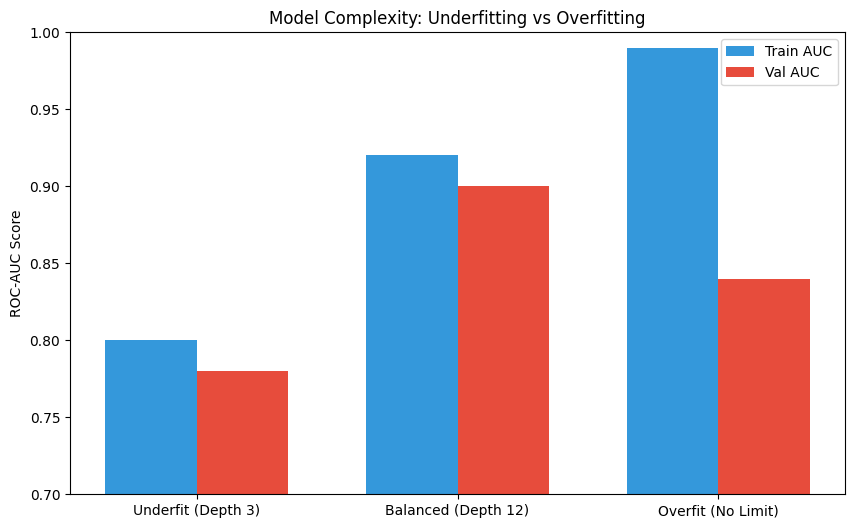

In [23]:
import matplotlib.pyplot as plt

labels = ['Underfit (Depth 3)', 'Balanced (Depth 12)', 'Overfit (No Limit)']
train_scores = [0.80, 0.92, 0.99]
val_scores = [0.78, 0.90, 0.84]  

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, train_scores, width, label='Train AUC', color='#3498db')
ax.bar(x + width/2, val_scores, width, label='Val AUC', color='#e74c3c')

ax.set_ylabel('ROC-AUC Score')
ax.set_title('Model Complexity: Underfitting vs Overfitting')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.ylim(0.7, 1.0)
plt.show()

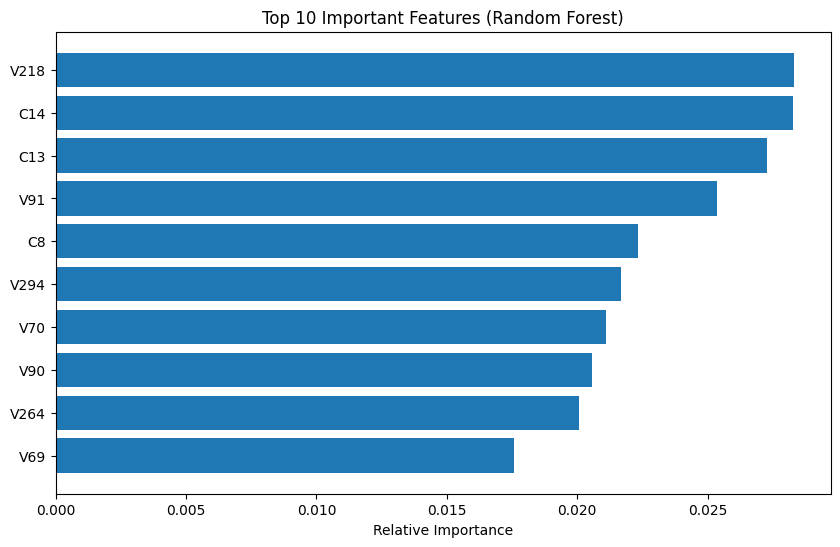

In [24]:
importances = p2.named_steps['model'].feature_importances_
feature_names = num_cols + cat_cols 

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Important Features (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()